In [1]:
# ============================================================
# STEP 2 - CELL 1
# SETUP
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import gc
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)

INPUT_DIR = Path("/kaggle/input")
OUTPUT_DIR = Path("/kaggle/working/step2")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 70)
print("STEP 2 - EXPLORATORY DATA ANALYSIS")
print("=" * 70)

print("Input :", INPUT_DIR)
print("Output:", OUTPUT_DIR)

print("\n✅ Setup completed")

STEP 2 - EXPLORATORY DATA ANALYSIS
Input : /kaggle/input
Output: /kaggle/working/step2

✅ Setup completed


In [2]:
# ============================================================
# STEP 2 - CELL 2
# DISCOVER & LOAD DATA
# ============================================================

print("=" * 70)
print("DISCOVER DATASETS")
print("=" * 70)

def find_file(filename):

    matches = list(
        INPUT_DIR.rglob(filename)
    )

    if len(matches) == 0:
        raise FileNotFoundError(
            f"{filename} not found"
        )

    if len(matches) > 1:
        print(
            f"⚠️ Multiple {filename} found. "
            f"Using: {matches[0]}"
        )

    return matches[0]


products_path = find_file(
    "products.csv"
)

reviews_path = find_file(
    "reviews.csv"
)

interactions_path = find_file(
    "interactions.csv"
)


print("\nFiles:")
print("Products    :", products_path)
print("Reviews     :", reviews_path)
print("Interactions:", interactions_path)


print("\nLoading datasets...")

products = pd.read_csv(
    products_path,
    low_memory=False
)

reviews = pd.read_csv(
    reviews_path,
    low_memory=False
)

interactions = pd.read_csv(
    interactions_path,
    low_memory=False
)


print("\n" + "=" * 70)
print("DATA LOADED")
print("=" * 70)

print(
    f"Products     : {products.shape}"
)

print(
    f"Reviews      : {reviews.shape}"
)

print(
    f"Interactions : {interactions.shape}"
)

print("\n✅ Data loaded")

DISCOVER DATASETS

Files:
Products    : /kaggle/input/datasets/trnquangtriu/2dataset/products.csv
Reviews     : /kaggle/input/datasets/trnquangtriu/2dataset/reviews.csv
Interactions: /kaggle/input/datasets/trnquangtriu/2dataset/interactions.csv

Loading datasets...

DATA LOADED
Products     : (164926, 15)
Reviews      : (767179, 11)
Interactions : (767179, 5)

✅ Data loaded


In [3]:
# ============================================================
# STEP 2 - CELL 3
# DATASET OVERVIEW
# ============================================================

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

overview = pd.DataFrame({

    "dataset": [
        "Products",
        "Reviews",
        "Interactions"
    ],

    "rows": [
        len(products),
        len(reviews),
        len(interactions)
    ],

    "columns": [
        products.shape[1],
        reviews.shape[1],
        interactions.shape[1]
    ],

    "memory_mb": [
        products.memory_usage(
            deep=True
        ).sum() / 1024**2,

        reviews.memory_usage(
            deep=True
        ).sum() / 1024**2,

        interactions.memory_usage(
            deep=True
        ).sum() / 1024**2
    ]
})

overview["memory_mb"] = (
    overview["memory_mb"]
    .round(2)
)

display(overview)


print("\nPRODUCT COLUMNS")
print(products.columns.tolist())

print("\nREVIEW COLUMNS")
print(reviews.columns.tolist())

print("\nINTERACTION COLUMNS")
print(interactions.columns.tolist())

DATASET OVERVIEW


,dataset,rows,columns,memory_mb
0,Products,164926,15,121.73
1,Reviews,767179,11,589.81
2,Interactions,767179,5,161.15



PRODUCT COLUMNS
['product_id', 'product_name', 'category', 'subcategory', 'brand', 'price', 'currency', 'average_rating', 'review_count', 'sold_count', 'description', 'image_url', 'product_url', 'source', 'language']

REVIEW COLUMNS
['review_id', 'user_id', 'product_id', 'rating', 'review_title', 'review_text', 'timestamp', 'verified_purchase', 'helpful_vote', 'language', 'source']

INTERACTION COLUMNS
['user_id', 'product_id', 'rating', 'timestamp', 'source']


# SOURCE DISTRIBUTION


In [4]:
# ============================================================
# STEP 2 - CELL 4
# SOURCE DISTRIBUTION
# ============================================================

print("=" * 70)
print("SOURCE DISTRIBUTION")
print("=" * 70)


# ------------------------------------------------------------
# Products
# ------------------------------------------------------------

product_source = (
    products["source"]
    .value_counts()
    .rename_axis("source")
    .reset_index(name="products")
)

product_source["percentage"] = (
    product_source["products"]
    / len(products)
    * 100
).round(2)


print("\n[1] PRODUCTS BY SOURCE")
display(product_source)


# ------------------------------------------------------------
# Reviews
# ------------------------------------------------------------

review_source = (
    reviews["source"]
    .value_counts()
    .rename_axis("source")
    .reset_index(name="reviews")
)

review_source["percentage"] = (
    review_source["reviews"]
    / len(reviews)
    * 100
).round(2)


print("\n[2] REVIEWS BY SOURCE")
display(review_source)


# ------------------------------------------------------------
# Interactions
# ------------------------------------------------------------

interaction_source = (
    interactions["source"]
    .value_counts()
    .rename_axis("source")
    .reset_index(name="interactions")
)

interaction_source["percentage"] = (
    interaction_source["interactions"]
    / len(interactions)
    * 100
).round(2)


print("\n[3] INTERACTIONS BY SOURCE")
display(interaction_source)


# ------------------------------------------------------------
# Language
# ------------------------------------------------------------

print("\n[4] PRODUCTS BY LANGUAGE")

display(
    products["language"]
    .value_counts(dropna=False)
    .rename_axis("language")
    .reset_index(name="products")
)


print("\n[5] REVIEWS BY LANGUAGE")

display(
    reviews["language"]
    .value_counts(dropna=False)
    .rename_axis("language")
    .reset_index(name="reviews")
)

SOURCE DISTRIBUTION

[1] PRODUCTS BY SOURCE


,source,products,percentage
0,amazon,121917,73.92
1,tiki,41575,25.21
2,shopee,1434,0.87



[2] REVIEWS BY SOURCE


,source,reviews,percentage
0,amazon,736093,95.95
1,shopee,31086,4.05



[3] INTERACTIONS BY SOURCE


,source,interactions,percentage
0,amazon,736093,95.95
1,shopee,31086,4.05



[4] PRODUCTS BY LANGUAGE


,language,products
0,en,121917
1,vi,43009



[5] REVIEWS BY LANGUAGE


,language,reviews
0,en,736093
1,vi,31086


# MISSING VALUE ANALYSIS


In [5]:
# ============================================================
# STEP 2 - CELL 5
# MISSING VALUE ANALYSIS
# ============================================================

print("=" * 70)
print("MISSING VALUE ANALYSIS")
print("=" * 70)


def missing_report(df):

    result = pd.DataFrame({
        "missing": df.isna().sum()
    })

    result["missing_%"] = (
        result["missing"]
        / len(df)
        * 100
    ).round(2)

    result["available"] = (
        len(df)
        - result["missing"]
    )

    return (
        result
        .sort_values(
            "missing_%",
            ascending=False
        )
    )


print("\n[1] PRODUCTS")
display(
    missing_report(products)
)


print("\n[2] REVIEWS")
display(
    missing_report(reviews)
)


print("\n[3] INTERACTIONS")
display(
    missing_report(interactions)
)

MISSING VALUE ANALYSIS

[1] PRODUCTS


,missing,missing_%,available
product_url,164926,100.00,0
image_url,163492,99.13,1434
subcategory,163492,99.13,1434
sold_count,123351,74.79,41575
description,123351,74.79,41575
category,1966,1.19,162960
brand,1498,0.91,163428
price,1434,0.87,163492
currency,0,0.00,164926
product_id,0,0.00,164926



[2] REVIEWS


,missing,missing_%,available
review_title,31238,4.07,735941
verified_purchase,31086,4.05,736093
helpful_vote,31086,4.05,736093
review_text,403,0.05,766776
product_id,0,0.00,767179
review_id,0,0.00,767179
user_id,0,0.00,767179
timestamp,0,0.00,767179
rating,0,0.00,767179
language,0,0.00,767179



[3] INTERACTIONS


,missing,missing_%,available
user_id,0,0.0,767179
product_id,0,0.0,767179
rating,0,0.0,767179
timestamp,0,0.0,767179
source,0,0.0,767179


# PRODUCT FIELD COVERAGE BY SOURCE


In [6]:
# ============================================================
# STEP 2 - CELL 6
# PRODUCT FIELD COVERAGE BY SOURCE
# ============================================================

print("=" * 70)
print("PRODUCT FIELD COVERAGE BY SOURCE")
print("=" * 70)

fields = [
    "product_name",
    "category",
    "subcategory",
    "brand",
    "price",
    "average_rating",
    "review_count",
    "sold_count",
    "description",
    "image_url",
    "product_url"
]

coverage_rows = []

for source, group in products.groupby(
    "source"
):

    for field in fields:

        if field not in group.columns:
            continue

        available = (
            group[field]
            .notna()
            .sum()
        )

        coverage_rows.append({

            "source": source,

            "field": field,

            "available": available,

            "total": len(group),

            "coverage_%": round(
                available
                / len(group)
                * 100,
                2
            )
        })


coverage = pd.DataFrame(
    coverage_rows
)

coverage_pivot = (
    coverage
    .pivot(
        index="field",
        columns="source",
        values="coverage_%"
    )
    .fillna(0)
)

display(
    coverage_pivot
)

PRODUCT FIELD COVERAGE BY SOURCE


source,amazon,shopee,tiki
field,,,
average_rating,100.00,100.0,100.0
brand,99.95,0.0,100.0
category,98.39,100.0,100.0
description,0.00,0.0,100.0
image_url,0.00,100.0,0.0
price,100.00,0.0,100.0
product_name,100.00,100.0,100.0
product_url,0.00,0.0,0.0
review_count,100.00,100.0,100.0


# RATING DISTRIBUTION


In [7]:
# ============================================================
# STEP 2 - CELL 7
# RATING DISTRIBUTION
# ============================================================

print("=" * 70)
print("RATING DISTRIBUTION")
print("=" * 70)

rating_table = (
    interactions
    .groupby(
        ["source", "rating"]
    )
    .size()
    .reset_index(
        name="count"
    )
)

rating_table["percentage"] = (
    rating_table
    .groupby("source")["count"]
    .transform(
        lambda x:
        x / x.sum() * 100
    )
    .round(2)
)

display(
    rating_table
)


print("\nRATING STATISTICS BY SOURCE")

display(
    interactions
    .groupby("source")["rating"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )
    .round(3)
)

RATING DISTRIBUTION


,source,rating,count,percentage
0,amazon,1.0,62538,8.50
1,amazon,2.0,32209,4.38
2,amazon,3.0,48503,6.59
3,amazon,4.0,96970,13.17
4,amazon,5.0,495873,67.37
5,shopee,1.0,261,0.84
6,shopee,2.0,90,0.29
7,shopee,3.0,263,0.85
8,shopee,4.0,901,2.90
9,shopee,5.0,29571,95.13



RATING STATISTICS BY SOURCE


,count,mean,median,std,min,max
source,,,,,,
amazon,736093,4.265,5.0,1.268,1.0,5.0
shopee,31086,4.912,5.0,0.464,1.0,5.0


# USER ACTIVITY ANALYSIS


In [8]:
# ============================================================
# STEP 2 - CELL 8
# USER ACTIVITY ANALYSIS
# ============================================================

print("=" * 70)
print("USER ACTIVITY ANALYSIS")
print("=" * 70)

user_activity = (
    interactions
    .groupby(
        ["source", "user_id"]
    )
    .size()
    .reset_index(
        name="interaction_count"
    )
)


print("\n[1] USER ACTIVITY STATISTICS")

display(
    user_activity
    .groupby("source")[
        "interaction_count"
    ]
    .describe(
        percentiles=[
            .25,
            .50,
            .75,
            .90,
            .95,
            .99
        ]
    )
    .round(2)
)


print("\n[2] USER THRESHOLDS")

threshold_rows = []

for source, group in user_activity.groupby(
    "source"
):

    total_users = len(group)

    for threshold in [
        1,
        2,
        3,
        5,
        10,
        20,
        50
    ]:

        count = (
            group["interaction_count"]
            >= threshold
        ).sum()

        threshold_rows.append({

            "source": source,

            "min_interactions":
                threshold,

            "users":
                count,

            "percentage":
                round(
                    count /
                    total_users *
                    100,
                    2
                )
        })


user_thresholds = pd.DataFrame(
    threshold_rows
)

display(
    user_thresholds
)

USER ACTIVITY ANALYSIS

[1] USER ACTIVITY STATISTICS


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
source,,,,,,,,,,,
amazon,198427.0,3.71,6.81,1.0,1.0,2.0,4.0,8.0,12.0,28.0,572.0
shopee,29888.0,1.04,0.22,1.0,1.0,1.0,1.0,1.0,1.0,2.0,5.0



[2] USER THRESHOLDS


,source,min_interactions,users,percentage
0,amazon,1,198427,100.00
1,amazon,2,117089,59.01
2,amazon,3,77578,39.10
3,amazon,5,41313,20.82
4,amazon,10,14577,7.35
5,amazon,20,4067,2.05
6,amazon,50,565,0.28
7,shopee,1,29888,100.00
8,shopee,2,1065,3.56
9,shopee,3,115,0.38


# PRODUCT ACTIVITY ANALYSIS


In [9]:
# ============================================================
# STEP 2 - CELL 9
# PRODUCT ACTIVITY ANALYSIS
# ============================================================

print("=" * 70)
print("PRODUCT ACTIVITY ANALYSIS")
print("=" * 70)

product_activity = (
    interactions
    .groupby(
        ["source", "product_id"]
    )
    .size()
    .reset_index(
        name="interaction_count"
    )
)


print("\n[1] PRODUCT ACTIVITY STATISTICS")

display(
    product_activity
    .groupby("source")[
        "interaction_count"
    ]
    .describe(
        percentiles=[
            .25,
            .50,
            .75,
            .90,
            .95,
            .99
        ]
    )
    .round(2)
)


print("\n[2] PRODUCT THRESHOLDS")

threshold_rows = []

for source, group in product_activity.groupby(
    "source"
):

    total_products = len(group)

    for threshold in [
        1,
        2,
        3,
        5,
        10,
        20,
        50,
        100
    ]:

        count = (
            group["interaction_count"]
            >= threshold
        ).sum()

        threshold_rows.append({

            "source":
                source,

            "min_interactions":
                threshold,

            "products":
                count,

            "percentage":
                round(
                    count /
                    total_products *
                    100,
                    2
                )
        })


product_thresholds = pd.DataFrame(
    threshold_rows
)

display(
    product_thresholds
)

PRODUCT ACTIVITY ANALYSIS

[1] PRODUCT ACTIVITY STATISTICS


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
source,,,,,,,,,,,
amazon,121917.0,6.04,33.05,1.0,1.0,2.0,4.0,10.0,20.0,72.0,5341.0
shopee,1434.0,21.68,3.29,3.0,21.0,23.0,24.0,24.0,24.0,24.0,30.0



[2] PRODUCT THRESHOLDS


,source,min_interactions,products,percentage
0,amazon,1,121917,100.00
1,amazon,2,66475,54.52
2,amazon,3,45234,37.10
3,amazon,5,27571,22.61
4,amazon,10,13440,11.02
5,amazon,20,6158,5.05
6,amazon,50,1957,1.61
7,amazon,100,785,0.64
8,shopee,1,1434,100.00
9,shopee,2,1434,100.00


# USER-PRODUCT MATRIX SPARSITY


In [10]:
# ============================================================
# STEP 2 - CELL 10
# USER-PRODUCT MATRIX SPARSITY
# ============================================================

print("=" * 70)
print("USER-PRODUCT MATRIX SPARSITY")
print("=" * 70)

sparsity_rows = []

for source, group in interactions.groupby(
    "source"
):

    n_users = (
        group["user_id"]
        .nunique()
    )

    n_products = (
        group["product_id"]
        .nunique()
    )

    n_interactions = len(group)

    possible = (
        n_users *
        n_products
    )

    density = (
        n_interactions /
        possible
        if possible > 0
        else 0
    )

    sparsity = (
        1 - density
    ) * 100

    sparsity_rows.append({

        "source":
            source,

        "users":
            n_users,

        "products":
            n_products,

        "interactions":
            n_interactions,

        "density":
            density,

        "sparsity_%":
            sparsity
    })


sparsity_df = pd.DataFrame(
    sparsity_rows
)

display(
    sparsity_df
    .style
    .format({
        "density": "{:.8f}",
        "sparsity_%": "{:.6f}"
    })
)

USER-PRODUCT MATRIX SPARSITY


,source,users,products,interactions,density,sparsity_%
0,amazon,198427,121917,736093,0.00003043,99.996957
1,shopee,29888,1434,31086,0.00072530,99.927470


# BUILD AMAZON CF K-CORE


In [11]:
# ============================================================
# STEP 2 - CELL 11
# BUILD AMAZON CF K-CORE
# ============================================================

print("=" * 70)
print("AMAZON CF K-CORE FILTERING")
print("=" * 70)

MIN_USER_INTERACTIONS = 5
MIN_PRODUCT_INTERACTIONS = 5

amazon_cf = (
    interactions[
        interactions["source"] == "amazon"
    ]
    .copy()
    .reset_index(drop=True)
)

print("\nBefore filtering")
print("-" * 70)

print("Interactions :", f"{len(amazon_cf):,}")
print("Users        :", f"{amazon_cf['user_id'].nunique():,}")
print("Products     :", f"{amazon_cf['product_id'].nunique():,}")


# ============================================================
# ITERATIVE K-CORE
# ============================================================

iteration = 0

while True:

    iteration += 1

    before_rows = len(amazon_cf)
    before_users = amazon_cf["user_id"].nunique()
    before_products = amazon_cf["product_id"].nunique()

    # --------------------------------------------------------
    # Filter users
    # --------------------------------------------------------

    user_counts = (
        amazon_cf["user_id"]
        .value_counts()
    )

    valid_users = user_counts[
        user_counts >= MIN_USER_INTERACTIONS
    ].index

    amazon_cf = amazon_cf[
        amazon_cf["user_id"].isin(valid_users)
    ].copy()


    # --------------------------------------------------------
    # Filter products
    # --------------------------------------------------------

    product_counts = (
        amazon_cf["product_id"]
        .value_counts()
    )

    valid_products = product_counts[
        product_counts >= MIN_PRODUCT_INTERACTIONS
    ].index

    amazon_cf = amazon_cf[
        amazon_cf["product_id"].isin(valid_products)
    ].copy()


    # --------------------------------------------------------
    # Statistics after iteration
    # --------------------------------------------------------

    after_rows = len(amazon_cf)
    after_users = amazon_cf["user_id"].nunique()
    after_products = amazon_cf["product_id"].nunique()

    print(
        f"Iteration {iteration:02d} | "
        f"Interactions: {after_rows:,} | "
        f"Users: {after_users:,} | "
        f"Products: {after_products:,}"
    )


    # --------------------------------------------------------
    # Stop when stable
    # --------------------------------------------------------

    if (
        before_rows == after_rows
        and before_users == after_users
        and before_products == after_products
    ):
        break


amazon_cf = amazon_cf.reset_index(drop=True)


# ============================================================
# FINAL VALIDATION
# ============================================================

final_user_counts = (
    amazon_cf["user_id"]
    .value_counts()
)

final_product_counts = (
    amazon_cf["product_id"]
    .value_counts()
)


print("\n" + "=" * 70)
print("FINAL AMAZON CF CORE")
print("=" * 70)

print(
    "Interactions :",
    f"{len(amazon_cf):,}"
)

print(
    "Users        :",
    f"{amazon_cf['user_id'].nunique():,}"
)

print(
    "Products     :",
    f"{amazon_cf['product_id'].nunique():,}"
)

print(
    "Min user interactions:",
    final_user_counts.min()
)

print(
    "Min product interactions:",
    final_product_counts.min()
)

print(
    "Mean interactions/user:",
    round(final_user_counts.mean(), 2)
)

print(
    "Mean interactions/product:",
    round(final_product_counts.mean(), 2)
)


assert final_user_counts.min() >= MIN_USER_INTERACTIONS
assert final_product_counts.min() >= MIN_PRODUCT_INTERACTIONS

print("\n✅ K-core constraints satisfied")

AMAZON CF K-CORE FILTERING

Before filtering
----------------------------------------------------------------------
Interactions : 736,093
Users        : 198,427
Products     : 121,917
Iteration 01 | Interactions: 321,297 | Users: 41,222 | Products: 18,618
Iteration 02 | Interactions: 270,885 | Users: 28,653 | Products: 16,167
Iteration 03 | Interactions: 265,015 | Users: 27,420 | Products: 15,899
Iteration 04 | Interactions: 264,266 | Users: 27,274 | Products: 15,857
Iteration 05 | Interactions: 264,094 | Users: 27,245 | Products: 15,843
Iteration 06 | Interactions: 264,050 | Users: 27,238 | Products: 15,839
Iteration 07 | Interactions: 264,026 | Users: 27,234 | Products: 15,837
Iteration 08 | Interactions: 264,018 | Users: 27,232 | Products: 15,837
Iteration 09 | Interactions: 264,018 | Users: 27,232 | Products: 15,837

FINAL AMAZON CF CORE
Interactions : 264,018
Users        : 27,232
Products     : 15,837
Min user interactions: 5
Min product interactions: 5
Mean interactions/user: 9

# CF CORE QUALITY ANALYSIS


In [12]:
# ============================================================
# STEP 2 - CELL 12
# CF CORE QUALITY ANALYSIS
# ============================================================

print("=" * 70)
print("CF CORE QUALITY ANALYSIS")
print("=" * 70)

original_amazon = interactions[
    interactions["source"] == "amazon"
]

original_users = original_amazon["user_id"].nunique()
original_products = original_amazon["product_id"].nunique()
original_interactions = len(original_amazon)

cf_users = amazon_cf["user_id"].nunique()
cf_products = amazon_cf["product_id"].nunique()
cf_interactions = len(amazon_cf)


comparison = pd.DataFrame({

    "metric": [
        "Interactions",
        "Users",
        "Products"
    ],

    "Original Amazon": [
        original_interactions,
        original_users,
        original_products
    ],

    "CF Core": [
        cf_interactions,
        cf_users,
        cf_products
    ]
})

comparison["Retained_%"] = (
    comparison["CF Core"]
    / comparison["Original Amazon"]
    * 100
).round(2)

display(comparison)


# ============================================================
# SPARSITY
# ============================================================

possible = (
    cf_users *
    cf_products
)

density = (
    cf_interactions /
    possible
)

sparsity = (
    1 - density
) * 100


print("\nCF MATRIX")
print("-" * 70)

print("Users       :", f"{cf_users:,}")
print("Products    :", f"{cf_products:,}")
print("Interactions:", f"{cf_interactions:,}")
print("Density     :", f"{density:.8f}")
print("Sparsity    :", f"{sparsity:.6f}%")


# ============================================================
# USER DISTRIBUTION
# ============================================================

print("\nUSER ACTIVITY AFTER K-CORE")
print("-" * 70)

print(
    final_user_counts.describe(
        percentiles=[
            .25,
            .50,
            .75,
            .90,
            .95,
            .99
        ]
    )
)


# ============================================================
# PRODUCT DISTRIBUTION
# ============================================================

print("\nPRODUCT ACTIVITY AFTER K-CORE")
print("-" * 70)

print(
    final_product_counts.describe(
        percentiles=[
            .25,
            .50,
            .75,
            .90,
            .95,
            .99
        ]
    )
)

CF CORE QUALITY ANALYSIS


,metric,Original Amazon,CF Core,Retained_%
0,Interactions,736093,264018,35.87
1,Users,198427,27232,13.72
2,Products,121917,15837,12.99



CF MATRIX
----------------------------------------------------------------------
Users       : 27,232
Products    : 15,837
Interactions: 264,018
Density     : 0.00061218
Sparsity    : 99.938782%

USER ACTIVITY AFTER K-CORE
----------------------------------------------------------------------
count    27232.000000
mean         9.695138
std          8.179209
min          5.000000
25%          5.000000
50%          7.000000
75%         11.000000
90%         17.000000
95%         23.000000
99%         44.000000
max        255.000000
Name: count, dtype: float64

PRODUCT ACTIVITY AFTER K-CORE
----------------------------------------------------------------------
count    15837.000000
mean        16.670960
std         33.973994
min          5.000000
25%          6.000000
50%          8.000000
75%         15.000000
90%         31.000000
95%         51.000000
99%        139.000000
max       1603.000000
Name: count, dtype: float64


# COLD-START / NON-CF COVERAGE ANALYSIS


In [13]:
# ============================================================
# STEP 2 - CELL 13
# COLD-START / NON-CF COVERAGE ANALYSIS
# ============================================================

print("=" * 70)
print("COLD-START / NON-CF COVERAGE ANALYSIS")
print("=" * 70)

cf_user_ids = set(
    amazon_cf["user_id"].unique()
)

cf_product_ids = set(
    amazon_cf["product_id"].unique()
)

# ------------------------------------------------------------
# Amazon full interaction population
# ------------------------------------------------------------

amazon_full = (
    interactions[
        interactions["source"] == "amazon"
    ]
)

amazon_all_users = set(
    amazon_full["user_id"].unique()
)

amazon_all_products = set(
    amazon_full["product_id"].unique()
)

# ------------------------------------------------------------
# Users outside CF
# ------------------------------------------------------------

non_cf_users = (
    amazon_all_users -
    cf_user_ids
)

non_cf_products = (
    amazon_all_products -
    cf_product_ids
)

# ------------------------------------------------------------
# Full product catalog
# ------------------------------------------------------------

all_catalog_products = set(
    products["product_id"].unique()
)

catalog_outside_cf = (
    all_catalog_products -
    cf_product_ids
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

cold_start_summary = pd.DataFrame({

    "metric": [
        "Amazon users with interactions",
        "Amazon users in CF core",
        "Amazon users outside CF core",

        "Amazon products with interactions",
        "Amazon products in CF core",
        "Amazon interaction-products outside CF",

        "Full catalog products",
        "Full catalog products outside CF core"
    ],

    "count": [
        len(amazon_all_users),
        len(cf_user_ids),
        len(non_cf_users),

        len(amazon_all_products),
        len(cf_product_ids),
        len(non_cf_products),

        len(all_catalog_products),
        len(catalog_outside_cf)
    ]
})

display(cold_start_summary)


print("\n[1] AMAZON USER CF COVERAGE")
print("-" * 70)

print(
    "CF users:",
    f"{len(cf_user_ids):,}",
    f"({len(cf_user_ids)/len(amazon_all_users)*100:.2f}%)"
)

print(
    "Outside CF:",
    f"{len(non_cf_users):,}",
    f"({len(non_cf_users)/len(amazon_all_users)*100:.2f}%)"
)


print("\n[2] AMAZON PRODUCT CF COVERAGE")
print("-" * 70)

print(
    "CF products:",
    f"{len(cf_product_ids):,}",
    f"({len(cf_product_ids)/len(amazon_all_products)*100:.2f}%)"
)

print(
    "Outside CF:",
    f"{len(non_cf_products):,}",
    f"({len(non_cf_products)/len(amazon_all_products)*100:.2f}%)"
)


print("\n[3] FULL CATALOG CF COVERAGE")
print("-" * 70)

print(
    "CF products:",
    f"{len(cf_product_ids):,}",
    f"({len(cf_product_ids)/len(all_catalog_products)*100:.2f}%)"
)

print(
    "Catalog outside CF:",
    f"{len(catalog_outside_cf):,}",
    f"({len(catalog_outside_cf)/len(all_catalog_products)*100:.2f}%)"
)

COLD-START / NON-CF COVERAGE ANALYSIS


,metric,count
0,Amazon users with interactions,198427
1,Amazon users in CF core,27232
2,Amazon users outside CF core,171195
3,Amazon products with interactions,121917
4,Amazon products in CF core,15837
5,Amazon interaction-products outside CF,106080
6,Full catalog products,164926
7,Full catalog products outside CF core,149089



[1] AMAZON USER CF COVERAGE
----------------------------------------------------------------------
CF users: 27,232 (13.72%)
Outside CF: 171,195 (86.28%)

[2] AMAZON PRODUCT CF COVERAGE
----------------------------------------------------------------------
CF products: 15,837 (12.99%)
Outside CF: 106,080 (87.01%)

[3] FULL CATALOG CF COVERAGE
----------------------------------------------------------------------
CF products: 15,837 (9.60%)
Catalog outside CF: 149,089 (90.40%)


# PRODUCT POPULARITY CONCENTRATION


In [14]:
# ============================================================
# STEP 2 - CELL 14
# PRODUCT POPULARITY CONCENTRATION
# ============================================================

print("=" * 70)
print("PRODUCT POPULARITY CONCENTRATION")
print("=" * 70)

amazon_product_popularity = (
    interactions[
        interactions["source"] == "amazon"
    ]
    .groupby("product_id")
    .size()
    .sort_values(
        ascending=False
    )
)

total_amazon_interactions = (
    amazon_product_popularity.sum()
)

rows = []

for pct in [
    0.01,
    0.05,
    0.10,
    0.20,
    0.50
]:

    n_products = max(
        1,
        int(
            np.ceil(
                len(amazon_product_popularity)
                * pct
            )
        )
    )

    covered = (
        amazon_product_popularity
        .iloc[:n_products]
        .sum()
    )

    rows.append({

        "top_product_%":
            pct * 100,

        "number_products":
            n_products,

        "interactions":
            covered,

        "interaction_share_%":
            round(
                covered /
                total_amazon_interactions *
                100,
                2
            )
    })

popularity_concentration = pd.DataFrame(
    rows
)

display(
    popularity_concentration
)

PRODUCT POPULARITY CONCENTRATION


,top_product_%,number_products,interactions,interaction_share_%
0,1.0,1220,219743,29.85
1,5.0,6096,388157,52.73
2,10.0,12192,474639,64.48
3,20.0,24384,562621,76.43
4,50.0,60959,669619,90.97


# CORE EDA VISUALIZATIONS


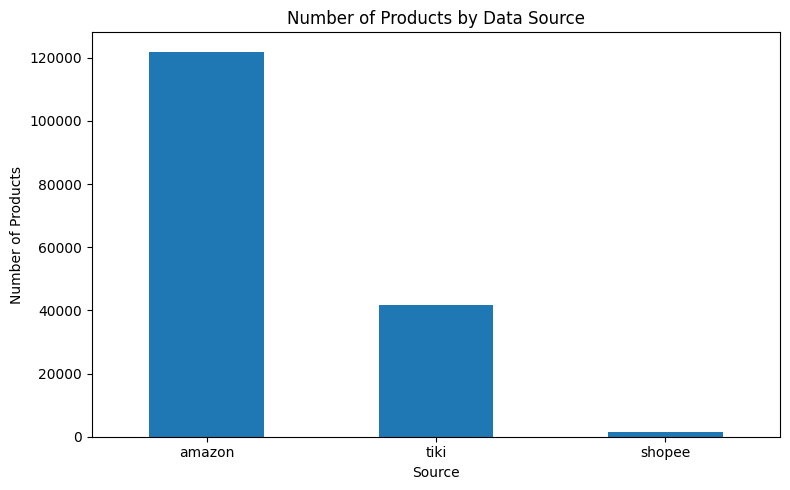

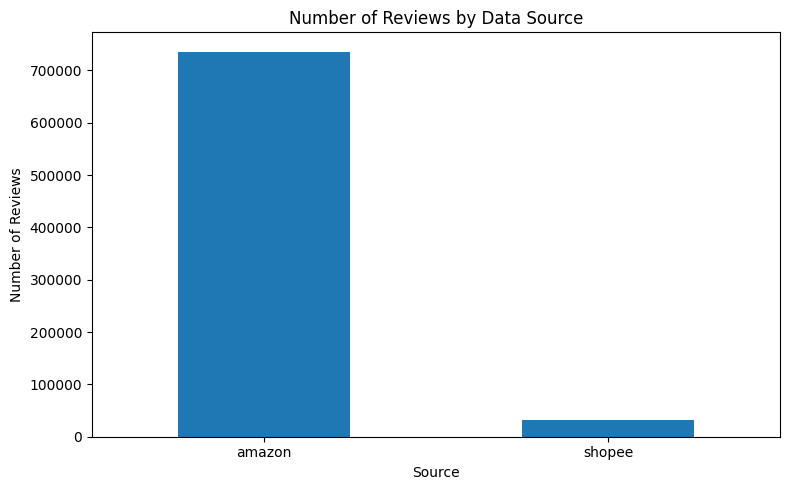

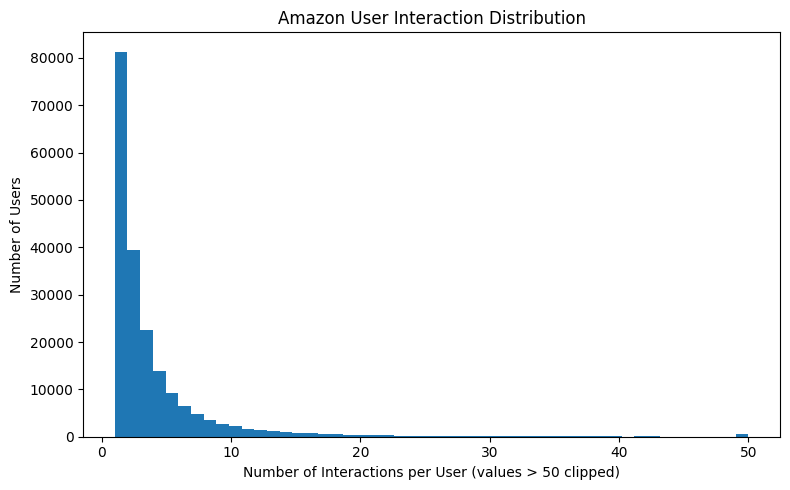

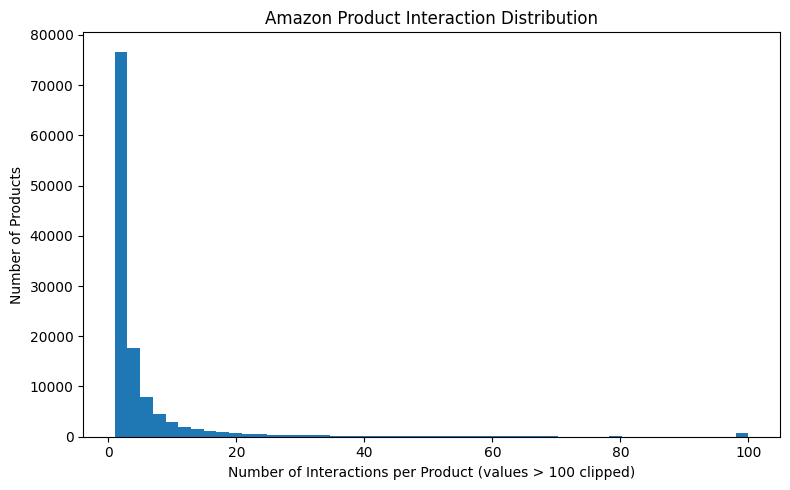

Figures saved to: /kaggle/working/step2/figures


In [15]:
# ============================================================
# STEP 2 - CELL 15
# CORE EDA VISUALIZATIONS
# ============================================================

FIG_DIR = OUTPUT_DIR / "figures"

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# FIGURE 1 - PRODUCTS BY SOURCE
# ============================================================

product_counts_plot = (
    products["source"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

product_counts_plot.plot(
    kind="bar"
)

plt.title(
    "Number of Products by Data Source"
)

plt.xlabel("Source")
plt.ylabel("Number of Products")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "products_by_source.png",
    dpi=200
)

plt.show()


# ============================================================
# FIGURE 2 - REVIEWS BY SOURCE
# ============================================================

review_counts_plot = (
    reviews["source"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

review_counts_plot.plot(
    kind="bar"
)

plt.title(
    "Number of Reviews by Data Source"
)

plt.xlabel("Source")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "reviews_by_source.png",
    dpi=200
)

plt.show()


# ============================================================
# FIGURE 3 - AMAZON USER ACTIVITY
# ============================================================

amazon_user_activity = (
    interactions[
        interactions["source"] == "amazon"
    ]
    .groupby("user_id")
    .size()
)

plt.figure(figsize=(8, 5))

plt.hist(
    amazon_user_activity.clip(upper=50),
    bins=50
)

plt.title(
    "Amazon User Interaction Distribution"
)

plt.xlabel(
    "Number of Interactions per User "
    "(values > 50 clipped)"
)

plt.ylabel("Number of Users")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "amazon_user_activity.png",
    dpi=200
)

plt.show()


# ============================================================
# FIGURE 4 - AMAZON PRODUCT ACTIVITY
# ============================================================

amazon_product_activity = (
    interactions[
        interactions["source"] == "amazon"
    ]
    .groupby("product_id")
    .size()
)

plt.figure(figsize=(8, 5))

plt.hist(
    amazon_product_activity.clip(upper=100),
    bins=50
)

plt.title(
    "Amazon Product Interaction Distribution"
)

plt.xlabel(
    "Number of Interactions per Product "
    "(values > 100 clipped)"
)

plt.ylabel("Number of Products")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "amazon_product_activity.png",
    dpi=200
)

plt.show()


print(
    "Figures saved to:",
    FIG_DIR
)

# RATING DISTRIBUTION VISUALIZATION


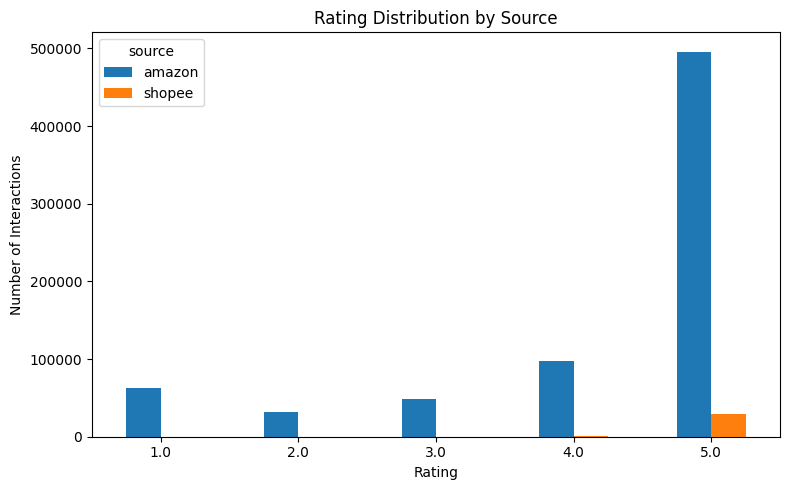

In [16]:
# ============================================================
# STEP 2 - CELL 16
# RATING DISTRIBUTION VISUALIZATION
# ============================================================

rating_counts = (
    interactions
    .groupby(
        ["source", "rating"]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .T
)

plt.figure(
    figsize=(8, 5)
)

rating_counts.plot(
    kind="bar",
    ax=plt.gca()
)

plt.title(
    "Rating Distribution by Source"
)

plt.xlabel("Rating")
plt.ylabel("Number of Interactions")

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "rating_distribution.png",
    dpi=200
)

plt.show()

# Chuẩn bị CF dataset cuối

In [17]:
# ============================================================
# STEP 2 - CELL 17
# USER-PRODUCT DUPLICATE AUDIT
# ============================================================

print("=" * 70)
print("CF USER-PRODUCT DUPLICATE AUDIT")
print("=" * 70)

pair_counts = (
    amazon_cf
    .groupby(
        [
            "user_id",
            "product_id"
        ]
    )
    .size()
)

duplicate_pairs = (
    pair_counts > 1
)

n_duplicate_pairs = int(
    duplicate_pairs.sum()
)

extra_interactions = int(
    (
        pair_counts[
            duplicate_pairs
        ] - 1
    ).sum()
)


print(
    "CF interactions:",
    f"{len(amazon_cf):,}"
)

print(
    "Unique user-product pairs:",
    f"{len(pair_counts):,}"
)

print(
    "Pairs appearing >1 time:",
    f"{n_duplicate_pairs:,}"
)

print(
    "Extra duplicate interactions:",
    f"{extra_interactions:,}"
)

print(
    "Duplicate interaction rate:",
    f"{extra_interactions / len(amazon_cf) * 100:.4f}%"
)


if n_duplicate_pairs > 0:

    print("\nSample duplicate pairs:")

    duplicate_index = (
        pair_counts[
            duplicate_pairs
        ]
        .head(10)
        .index
    )

    duplicate_sample = (
        amazon_cf
        .set_index(
            [
                "user_id",
                "product_id"
            ]
        )
        .loc[duplicate_index]
        .reset_index()
    )

    display(
        duplicate_sample
    )

else:

    print(
        "\n✅ No duplicate user-product pairs."
    )

CF USER-PRODUCT DUPLICATE AUDIT
CF interactions: 264,018
Unique user-product pairs: 261,491
Pairs appearing >1 time: 2,384
Extra duplicate interactions: 2,527
Duplicate interaction rate: 0.9571%

Sample duplicate pairs:


,user_id,product_id,rating,timestamp,source
0,amazon_AE27V7ISFPH3G6TKPILEWRJ4FBDQ,amazon_B07RRWZC2S,5.0,1493400674000,amazon
1,amazon_AE27V7ISFPH3G6TKPILEWRJ4FBDQ,amazon_B07RRWZC2S,5.0,1493400667000,amazon
2,amazon_AE2BCWBDERZKN3ACIXQQISI3LHPA,amazon_B013EKI2DY,5.0,1404830189000,amazon
3,amazon_AE2BCWBDERZKN3ACIXQQISI3LHPA,amazon_B013EKI2DY,5.0,1404830157000,amazon
4,amazon_AE2HYKDTOJKRWUF2CNBDJ5IWGFKA,amazon_B07XNGYMGS,5.0,1609856789997,amazon
5,amazon_AE2HYKDTOJKRWUF2CNBDJ5IWGFKA,amazon_B07XNGYMGS,5.0,1578847156842,amazon
6,amazon_AE2IAFB65XCDE6G2CDJUXB4ITZBQ,amazon_B09DVHKL3C,5.0,1651877175340,amazon
7,amazon_AE2IAFB65XCDE6G2CDJUXB4ITZBQ,amazon_B09DVHKL3C,1.0,1639705451255,amazon
8,amazon_AE2MTALCHX3JPELMR5FAVEXKGYJA,amazon_B0B59D5468,4.0,1415630809000,amazon
9,amazon_AE2MTALCHX3JPELMR5FAVEXKGYJA,amazon_B0B59D5468,5.0,1415630012000,amazon


# Deduplicate theo interaction mới nhất

In [18]:
# ============================================================
# STEP 2 - CELL 18
# DEDUPLICATE USER-PRODUCT INTERACTIONS
# KEEP LATEST INTERACTION
# ============================================================

print("=" * 70)
print("DEDUPLICATE CF INTERACTIONS")
print("=" * 70)

cf_dedup = amazon_cf.copy()

# ------------------------------------------------------------
# Ensure timestamp is numeric
# ------------------------------------------------------------

cf_dedup["timestamp"] = pd.to_numeric(
    cf_dedup["timestamp"],
    errors="coerce"
)

before = len(cf_dedup)

# ------------------------------------------------------------
# Sort oldest -> newest
# Keep newest user-product interaction
# ------------------------------------------------------------

cf_dedup = (
    cf_dedup
    .sort_values(
        "timestamp",
        ascending=True,
        na_position="first"
    )
    .drop_duplicates(
        subset=[
            "user_id",
            "product_id"
        ],
        keep="last"
    )
    .reset_index(drop=True)
)

removed = before - len(cf_dedup)

print(
    "Before dedup :",
    f"{before:,}"
)

print(
    "After dedup  :",
    f"{len(cf_dedup):,}"
)

print(
    "Removed      :",
    f"{removed:,}"
)

print(
    "Removed %    :",
    f"{removed / before * 100:.4f}%"
)

print(
    "\nDuplicate user-product pairs remaining:",
    cf_dedup.duplicated(
        ["user_id", "product_id"]
    ).sum()
)

assert (
    cf_dedup.duplicated(
        ["user_id", "product_id"]
    ).sum() == 0
)

print("\n✅ User-product pairs are unique")

DEDUPLICATE CF INTERACTIONS
Before dedup : 264,018
After dedup  : 261,491
Removed      : 2,527
Removed %    : 0.9571%

Duplicate user-product pairs remaining: 0

✅ User-product pairs are unique


In [19]:
# ============================================================
# STEP 2 - CELL 19
# FINAL 5-CORE AFTER DEDUPLICATION
# ============================================================

print("=" * 70)
print("FINAL CF 5-CORE AFTER DEDUPLICATION")
print("=" * 70)

MIN_USER_INTERACTIONS = 5
MIN_PRODUCT_INTERACTIONS = 5

cf_interactions = (
    cf_dedup
    .copy()
)

iteration = 0

while True:

    iteration += 1

    before_rows = len(cf_interactions)
    before_users = (
        cf_interactions["user_id"].nunique()
    )
    before_products = (
        cf_interactions["product_id"].nunique()
    )

    # --------------------------------------------------------
    # User filtering
    # --------------------------------------------------------

    user_counts = (
        cf_interactions["user_id"]
        .value_counts()
    )

    valid_users = (
        user_counts[
            user_counts >= MIN_USER_INTERACTIONS
        ]
        .index
    )

    cf_interactions = (
        cf_interactions[
            cf_interactions["user_id"]
            .isin(valid_users)
        ]
        .copy()
    )

    # --------------------------------------------------------
    # Product filtering
    # --------------------------------------------------------

    product_counts = (
        cf_interactions["product_id"]
        .value_counts()
    )

    valid_products = (
        product_counts[
            product_counts >= MIN_PRODUCT_INTERACTIONS
        ]
        .index
    )

    cf_interactions = (
        cf_interactions[
            cf_interactions["product_id"]
            .isin(valid_products)
        ]
        .copy()
    )

    after_rows = len(cf_interactions)
    after_users = (
        cf_interactions["user_id"].nunique()
    )
    after_products = (
        cf_interactions["product_id"].nunique()
    )

    print(
        f"Iteration {iteration:02d} | "
        f"Interactions: {after_rows:,} | "
        f"Users: {after_users:,} | "
        f"Products: {after_products:,}"
    )

    if (
        before_rows == after_rows
        and before_users == after_users
        and before_products == after_products
    ):
        break


cf_interactions = (
    cf_interactions
    .reset_index(drop=True)
)


# ============================================================
# VALIDATE
# ============================================================

final_user_counts = (
    cf_interactions["user_id"]
    .value_counts()
)

final_product_counts = (
    cf_interactions["product_id"]
    .value_counts()
)

n_users = (
    cf_interactions["user_id"]
    .nunique()
)

n_products = (
    cf_interactions["product_id"]
    .nunique()
)

n_interactions = len(
    cf_interactions
)

density = (
    n_interactions /
    (n_users * n_products)
)

sparsity = (
    1 - density
) * 100


print("\n" + "=" * 70)
print("FINAL CF DATASET")
print("=" * 70)

print(
    "Interactions :",
    f"{n_interactions:,}"
)

print(
    "Users        :",
    f"{n_users:,}"
)

print(
    "Products     :",
    f"{n_products:,}"
)

print(
    "Min user interactions:",
    final_user_counts.min()
)

print(
    "Min product interactions:",
    final_product_counts.min()
)

print(
    "Mean interactions/user:",
    f"{final_user_counts.mean():.2f}"
)

print(
    "Mean interactions/product:",
    f"{final_product_counts.mean():.2f}"
)

print(
    "Density      :",
    f"{density:.8f}"
)

print(
    "Sparsity     :",
    f"{sparsity:.6f}%"
)


assert final_user_counts.min() >= 5
assert final_product_counts.min() >= 5

assert (
    cf_interactions
    .duplicated(
        ["user_id", "product_id"]
    )
    .sum()
    == 0
)

print("\n✅ Final CF dataset passed all checks")

FINAL CF 5-CORE AFTER DEDUPLICATION
Iteration 01 | Interactions: 260,066 | Users: 27,036 | Products: 15,653
Iteration 02 | Interactions: 259,495 | Users: 26,917 | Products: 15,629
Iteration 03 | Interactions: 259,427 | Users: 26,903 | Products: 15,626
Iteration 04 | Interactions: 259,427 | Users: 26,903 | Products: 15,626

FINAL CF DATASET
Interactions : 259,427
Users        : 26,903
Products     : 15,626
Min user interactions: 5
Min product interactions: 5
Mean interactions/user: 9.64
Mean interactions/product: 16.60
Density      : 0.00061712
Sparsity     : 99.938288%

✅ Final CF dataset passed all checks


In [20]:
# ============================================================
# STEP 2 - CELL 20
# TEMPORAL SPLIT READINESS
# ============================================================

print("=" * 70)
print("TEMPORAL SPLIT READINESS")
print("=" * 70)

timestamp_valid = (
    cf_interactions["timestamp"]
    .notna()
)

print(
    "Interactions:",
    f"{len(cf_interactions):,}"
)

print(
    "Valid timestamps:",
    f"{timestamp_valid.sum():,}"
)

print(
    "Missing timestamps:",
    f"{(~timestamp_valid).sum():,}"
)

print(
    "Timestamp coverage:",
    f"{timestamp_valid.mean() * 100:.2f}%"
)


if timestamp_valid.any():

    timestamp_dt = pd.to_datetime(
        cf_interactions.loc[
            timestamp_valid,
            "timestamp"
        ],
        unit="ms",
        errors="coerce"
    )

    print(
        "\nEarliest:",
        timestamp_dt.min()
    )

    print(
        "Latest  :",
        timestamp_dt.max()
    )


# ------------------------------------------------------------
# Number of train interactions after holding out
# validation + test
# ------------------------------------------------------------

user_sizes = (
    cf_interactions
    .groupby("user_id")
    .size()
)

train_sizes = (
    user_sizes - 2
)

print("\nAfter future temporal split:")

print(
    "Minimum train interactions/user:",
    train_sizes.min()
)

print(
    "Median train interactions/user :",
    train_sizes.median()
)

print(
    "Mean train interactions/user   :",
    round(
        train_sizes.mean(),
        2
    )
)

assert train_sizes.min() >= 3

print(
    "\n✅ Every user can have "
    "Train >= 3 + Validation 1 + Test 1"
)

TEMPORAL SPLIT READINESS
Interactions: 259,427
Valid timestamps: 259,427
Missing timestamps: 0
Timestamp coverage: 100.00%

Earliest: 2000-07-12 19:54:59
Latest  : 2023-03-20 01:34:02.696000

After future temporal split:
Minimum train interactions/user: 3
Median train interactions/user : 5.0
Mean train interactions/user   : 7.64

✅ Every user can have Train >= 3 + Validation 1 + Test 1


In [21]:
# ============================================================
# STEP 2 - CELL 21
# BUILD EDA SUMMARY
# ============================================================

print("=" * 70)
print("BUILD EDA SUMMARY")
print("=" * 70)

summary_data = [

    # Full dataset
    ["full_catalog_products", len(products)],
    ["full_reviews", len(reviews)],
    ["full_interactions", len(interactions)],
    [
        "full_users",
        interactions["user_id"].nunique()
    ],

    # Source
    [
        "amazon_products",
        (products["source"] == "amazon").sum()
    ],
    [
        "tiki_products",
        (products["source"] == "tiki").sum()
    ],
    [
        "shopee_products",
        (products["source"] == "shopee").sum()
    ],

    [
        "amazon_reviews",
        (reviews["source"] == "amazon").sum()
    ],
    [
        "shopee_reviews",
        (reviews["source"] == "shopee").sum()
    ],

    # Original Amazon interaction data
    [
        "amazon_original_users",
        original_users
    ],
    [
        "amazon_original_products",
        original_products
    ],
    [
        "amazon_original_interactions",
        original_interactions
    ],

    # Final CF
    [
        "cf_min_user_interactions",
        MIN_USER_INTERACTIONS
    ],
    [
        "cf_min_product_interactions",
        MIN_PRODUCT_INTERACTIONS
    ],
    [
        "cf_users",
        n_users
    ],
    [
        "cf_products",
        n_products
    ],
    [
        "cf_interactions",
        n_interactions
    ],
    [
        "cf_density",
        density
    ],
    [
        "cf_sparsity_percent",
        sparsity
    ],

    # Popularity
    [
        "top_1pct_product_interaction_share",
        popularity_concentration.loc[
            popularity_concentration[
                "top_product_%"
            ] == 1.0,
            "interaction_share_%"
        ].iloc[0]
    ],

    [
        "top_10pct_product_interaction_share",
        popularity_concentration.loc[
            popularity_concentration[
                "top_product_%"
            ] == 10.0,
            "interaction_share_%"
        ].iloc[0]
    ]
]


eda_summary = pd.DataFrame(
    summary_data,
    columns=[
        "metric",
        "value"
    ]
)

display(
    eda_summary
)

BUILD EDA SUMMARY


,metric,value
0,full_catalog_products,164926.000000
1,full_reviews,767179.000000
2,full_interactions,767179.000000
3,full_users,228315.000000
4,amazon_products,121917.000000
5,tiki_products,41575.000000
6,shopee_products,1434.000000
7,amazon_reviews,736093.000000
8,shopee_reviews,31086.000000
9,amazon_original_users,198427.000000


In [22]:
# ============================================================
# STEP 2 - CELL 22
# SAVE STEP 2 OUTPUTS
# ============================================================

print("=" * 70)
print("SAVE STEP 2 OUTPUTS")
print("=" * 70)

cf_path = (
    OUTPUT_DIR /
    "cf_interactions.csv"
)

summary_path = (
    OUTPUT_DIR /
    "eda_summary.csv"
)

user_activity_path = (
    OUTPUT_DIR /
    "user_activity.csv"
)

product_activity_path = (
    OUTPUT_DIR /
    "product_activity.csv"
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

cf_interactions.to_csv(
    cf_path,
    index=False
)

eda_summary.to_csv(
    summary_path,
    index=False
)

user_activity.to_csv(
    user_activity_path,
    index=False
)

product_activity.to_csv(
    product_activity_path,
    index=False
)


# ------------------------------------------------------------
# Output report
# ------------------------------------------------------------

print("\nSaved files:")
print("-" * 70)

for path in [
    cf_path,
    summary_path,
    user_activity_path,
    product_activity_path
]:

    size_mb = (
        path.stat().st_size /
        (1024 ** 2)
    )

    print(
        f"{path.name:<30}"
        f"{size_mb:>10.2f} MB"
    )


print("\nSaved figures:")
print("-" * 70)

for path in sorted(
    FIG_DIR.glob("*.png")
):

    print(path.name)


print("\nOutput directory:")
print(OUTPUT_DIR)

print("\n" + "=" * 70)
print("✅ STEP 2 COMPLETED")
print("=" * 70)

SAVE STEP 2 OUTPUTS

Saved files:
----------------------------------------------------------------------
cf_interactions.csv                19.55 MB
eda_summary.csv                     0.00 MB
user_activity.csv                   9.27 MB
product_activity.csv                3.19 MB

Saved figures:
----------------------------------------------------------------------
amazon_product_activity.png
amazon_user_activity.png
products_by_source.png
rating_distribution.png
reviews_by_source.png

Output directory:
/kaggle/working/step2

✅ STEP 2 COMPLETED
